# Infrastructure-Based Adaptive Capacity: Access to Heat-Mitigating Resources and Essential Services
Adaptive capacity refers to the ability of individuals, communities, or systems to adjust to potential hazards, take advantage of opportunities, or cope with consequences. In the context of urban heat vulnerability, adaptive capacity is largely determined by proximity to and availability of infrastructure and services that can buffer heat stress - whether by providing cooling refuge, emergency care, or basic physiological needs such as hydration.
Following the widely used $$Vulnerability = Exposure * Sensitivity * Adaptive\ Capacity$$ framework (IPCC, 2014; Cutter et al., 2003), this section operationalises adaptive capacity through spatial accessibility indicators, quantifying how well different areas of Nairobi are served by key heat-mitigating resources.

## Setup

In [ ]:
import sys
sys.path.append('../.')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.adaptive_capacity_helper import (
    load_boundary, load_geojson, create_analysis_grid,
    compute_proximity, compute_road_density, compute_composite,
    plot_layer, plot_points_overlay, plot_all_layers,
    PROXIMITY_CMAP, COMPOSITE_CMAP
)

%load_ext autoreload
%autoreload 2
%matplotlib inline

Failed to read module file 'C:\Users\Surface\anaconda3\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Surface\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<fro

In [2]:
# --- Load boundary & create analysis grid -----------------------------
boundary = load_boundary()  # reads data/geospatial/nairobi_boundary.geojson
grid = create_analysis_grid(boundary, resolution_m=50)
print(f"Grid shape: {grid['nrows']} rows x {grid['ncols']} cols")
print(f"Cells inside boundary: {grid['mask'].sum():,}")

  Grid created: 631 x 982 cells (50 m resolution)
Grid shape: 631 rows x 982 cols
Cells inside boundary: 278,559


## 1 · Proximity to retail & food supply
Access to food and basic supplies is critical during heat events. This layer measures the Euclidean distance from every 50 m grid cell to the nearest retail/food point (supermarkets, convenience stores, marketplaces) sourced from OpenStreetMap.

  Loaded retail_food_nairobi.geojson: 653 features


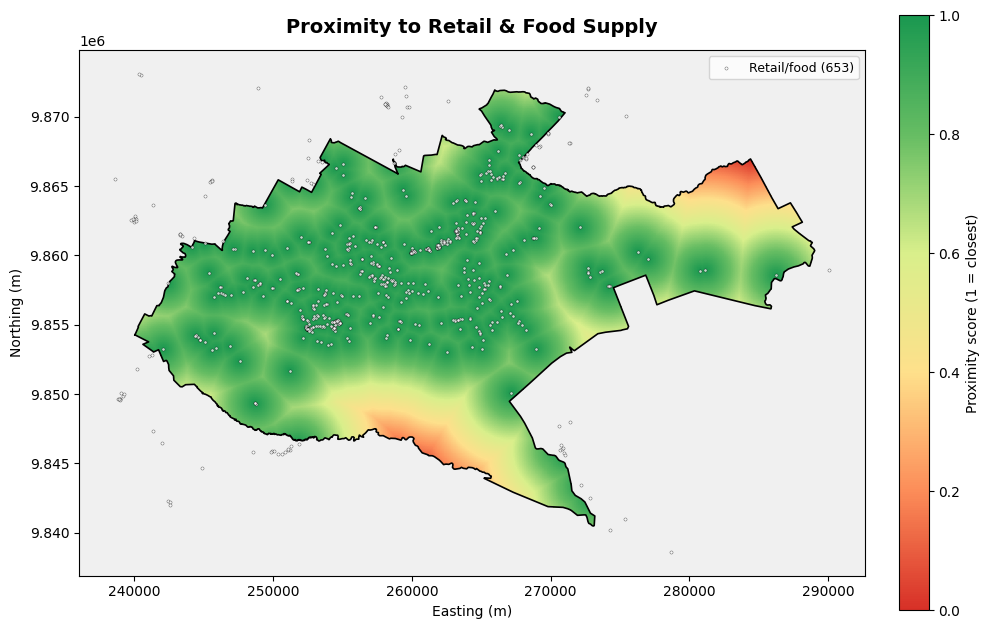

In [3]:
retail = load_geojson('retail_food_nairobi.geojson')

retail_proximity = compute_proximity(retail, grid)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(retail_proximity, grid,
           'Proximity to Retail & Food Supply',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(retail, grid, ax, color='white', size=5,
                    label=f'Retail/food ({len(retail)})')
plt.tight_layout()
plt.show()

## 2 · Healthcare accessibility
Proximity to health facilities determines how quickly residents can receive treatment for heat-related illness. We use the Kenya health-facilities dataset already available locally, filtered to Nairobi province.

  Loaded Health_facilities_Nairobi.geojson: 4867 features
  Filtered to Nairobi: 169 facilities


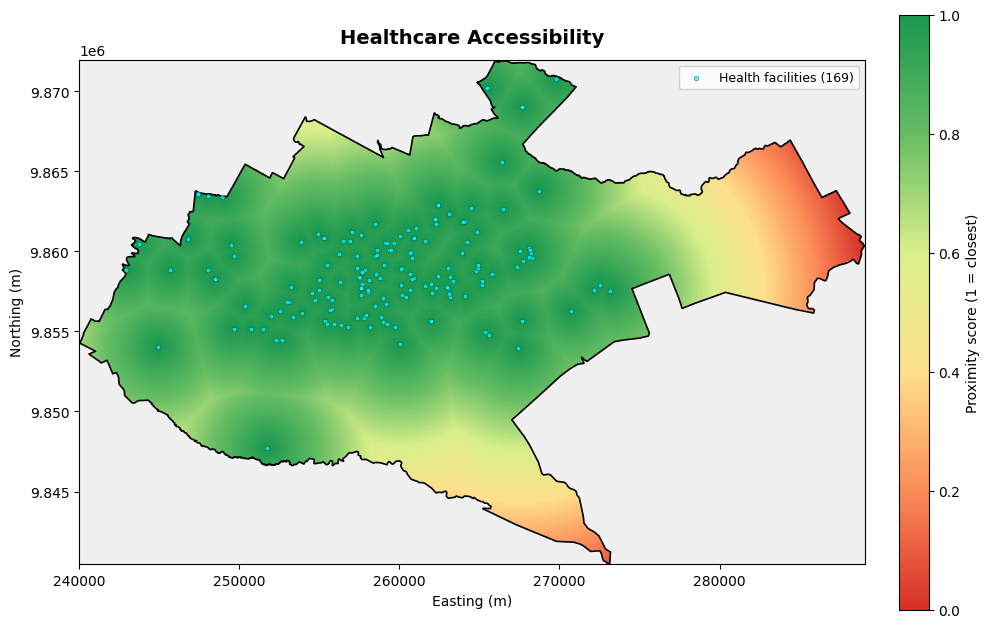

In [4]:
health_all = load_geojson('Health_facilities_Nairobi.geojson')

# Filter to Nairobi province
health = health_all[health_all['Province'] == 'NAIROBI'].copy()
print(f"  Filtered to Nairobi: {len(health)} facilities")

health_proximity = compute_proximity(health, grid)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(health_proximity, grid,
           'Healthcare Accessibility',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(health, grid, ax, color='cyan', size=12,
                    label=f'Health facilities ({len(health)})')
plt.tight_layout()
plt.show()

## 3 · Access to safe water sources
Hydration access is one of the most direct determinants of heat-stress resilience. This layer uses OSM drinking water points, water wells, and taps.

> **Caveat:** OSM coverage of water points in informal settlements is known to be incomplete, many informal water vendors are not mapped. Maybe the wheight that we give to this layer should be set accordingly

  Loaded water_sources_nairobi.geojson: 3266 features


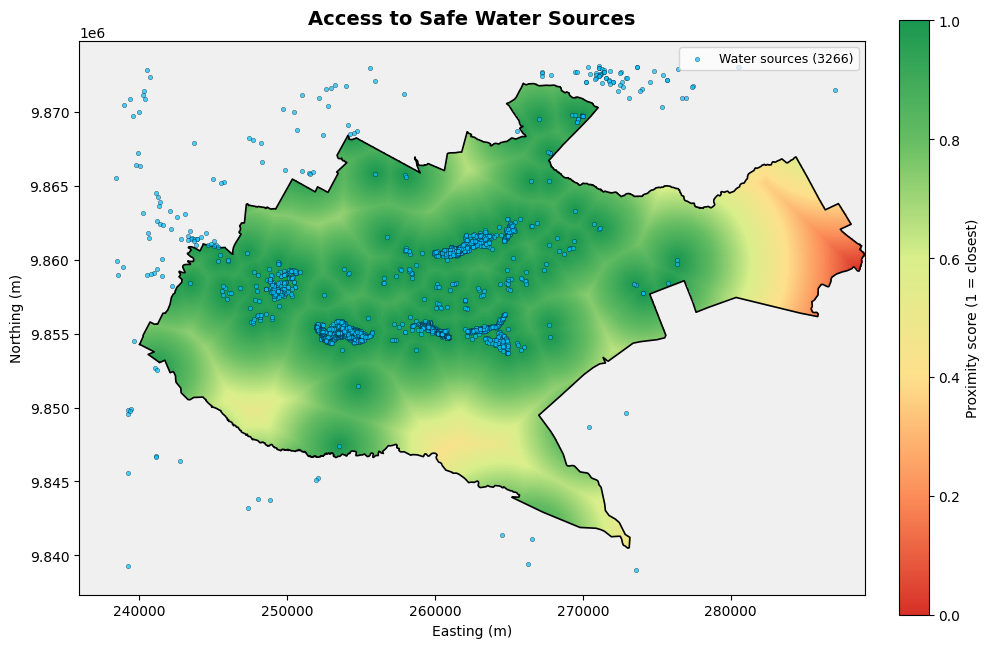

In [ ]:
water = load_geojson('water_sources_nairobi.geojson')

water_proximity = compute_proximity(water, grid)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(water_proximity, grid,
           'Access to Safe Water Sources',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(water, grid, ax, color='deepskyblue', size=10,
                    label=f'Water sources ({len(water)})')
plt.tight_layout()
plt.show()

## 4 · Urban green space accessibility
Parks, gardens, and forested areas provide shade and evapotranspiration cooling. This layer measures proximity to green-space centroids extracted from OSM.

  Loaded green_spaces_nairobi.geojson: 3119 features


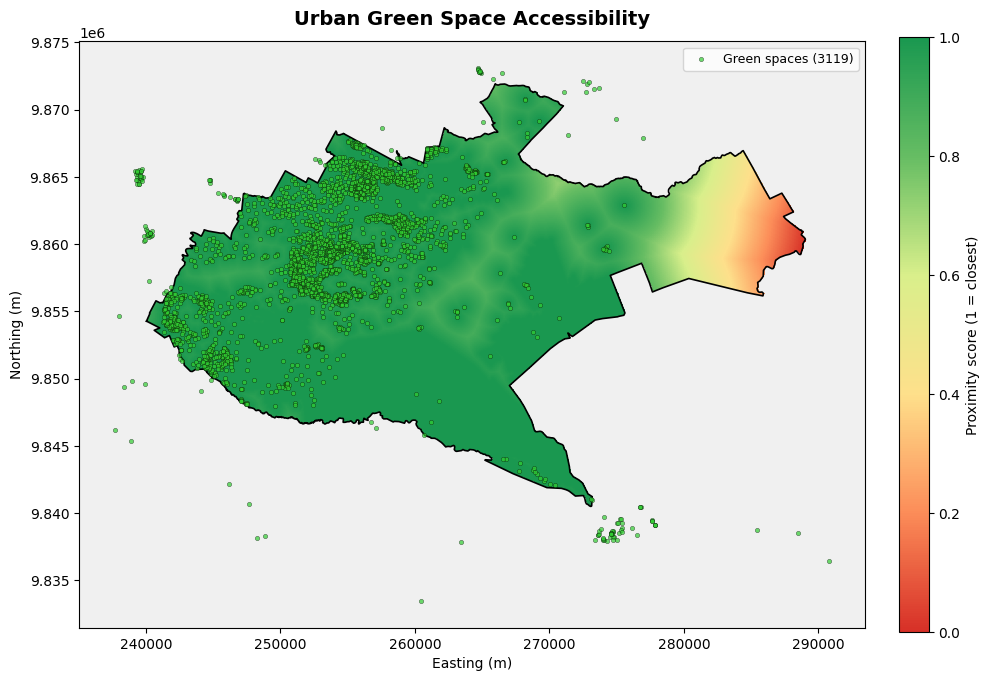

" ----- Plot the border of the greenspaces -------- (doesn't render this good make the plot look confuse)\ngreen = load_geojson('green_spaces_nairobi.geojson')\n\ngreen_proximity = compute_proximity(green, grid)\n\nfig, ax = plt.subplots(figsize=(10, 9))\nplot_layer(green_proximity, grid,\n           'Urban Green Space Accessibility',\n           cbar_label='Proximity score (1 = closest)', ax=ax)\n\n# Dissolve overlapping polygons into one, then plot clean boundaries\ngreen_utm = green.to_crs(grid['crs'])\nmerged = green_utm.unary_union\ngpd.GeoSeries([merged], crs=grid['crs']).boundary.plot(\n    ax=ax, color='limegreen', linewidth=0.8, alpha=0.7, zorder=5)\nax.legend(['Green spaces'], loc='upper right', fontsize=9)\nplt.tight_layout()\nplt.show()\n"

In [6]:
green = load_geojson('green_spaces_nairobi.geojson')

green_proximity = compute_proximity(green, grid)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(green_proximity, grid,
           'Urban Green Space Accessibility',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(green, grid, ax, color='limegreen', size=10,
                    label=f'Green spaces ({len(green)})')
plt.tight_layout()
plt.show()
''' ----- Plot the border of the greenspaces -------- (doesn't render this good make the plot look confuse)
green = load_geojson('green_spaces_nairobi.geojson')

green_proximity = compute_proximity(green, grid)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(green_proximity, grid,
           'Urban Green Space Accessibility',
           cbar_label='Proximity score (1 = closest)', ax=ax)

# Dissolve overlapping polygons into one, then plot clean boundaries
green_utm = green.to_crs(grid['crs'])
merged = green_utm.unary_union
gpd.GeoSeries([merged], crs=grid['crs']).boundary.plot(
    ax=ax, color='limegreen', linewidth=0.8, alpha=0.7, zorder=5)
ax.legend(['Green spaces'], loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()
'''

## 5 · Mobility & evacuation potential
Road network density reflects how easily residents can move to cooler areas or reach emergency services. We combine `major_roads.geojson` and `street_edges.geojson` and compute a Gaussian-smoothed road density surface.

  Loaded major_roads.geojson: 275 features
  Loaded street_edges.geojson: 48107 features
  Combined road segments: 48382


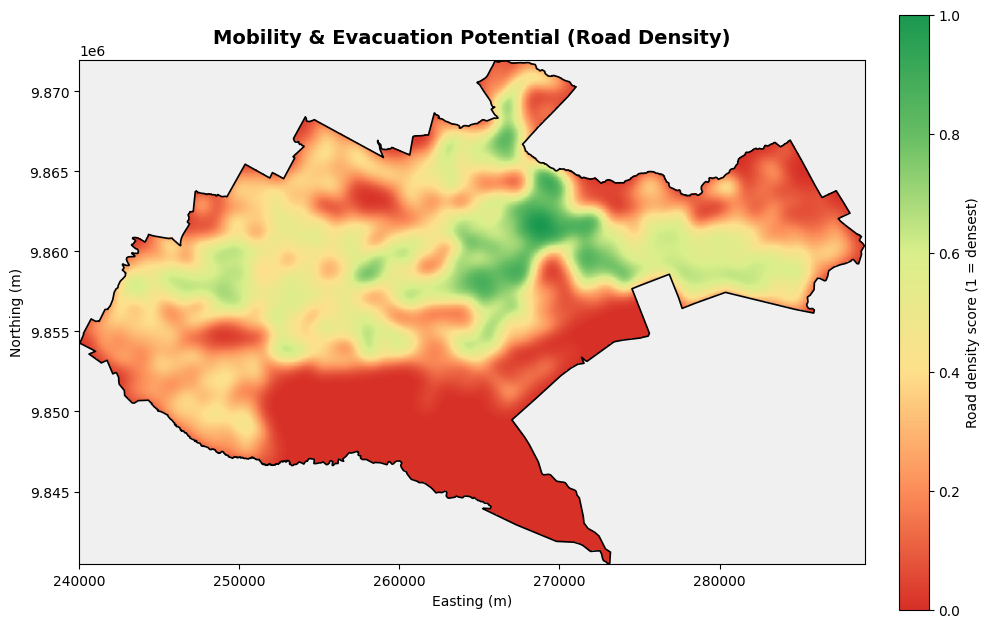

In [ ]:
major_roads = load_geojson('major_roads.geojson')
street_edges = load_geojson('street_edges.geojson')

# Combine both road layers
all_roads = gpd.GeoDataFrame(
    pd.concat([major_roads[['geometry']], street_edges[['geometry']]],
              ignore_index=True),
    crs=major_roads.crs
)
print(f"  Combined road segments: {len(all_roads)}")

mobility = compute_road_density(all_roads, grid, bandwidth_m=500)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(mobility, grid,
           'Mobility & Evacuation Potential (Road Density)',
           cbar_label='Road density score (1 = densest)', ax=ax)
plt.tight_layout()
plt.show()

## 6 · Cooling centre proximity
Public buildings that can serve as cooling refuges - libraries, community centres, places of worship, and social facilities - are mapped from OSM.

  Loaded cooling_centres_nairobi.geojson: 1849 features


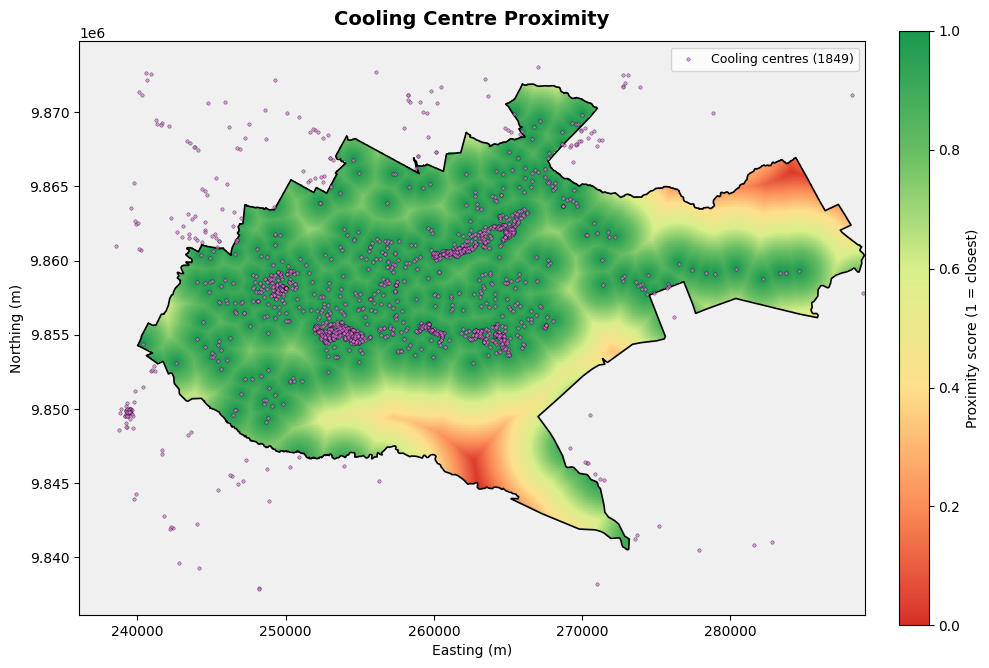

In [8]:
cooling = load_geojson('cooling_centres_nairobi.geojson')

cooling_proximity = compute_proximity(cooling, grid)

fig, ax = plt.subplots(figsize=(10, 9))
plot_layer(cooling_proximity, grid,
           'Cooling Centre Proximity',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(cooling, grid, ax, color='orchid', size=6,
                    label=f'Cooling centres ({len(cooling)})')
plt.tight_layout()
plt.show()

---
## Composite Adaptive Capacity Index
We combine all six normalised layers into a single Adaptive Capacity score using an **equal-weight average** ($w_i = 1/6$). The weights can be adjusted in future iterations based on domain expertise or sensitivity analysis.

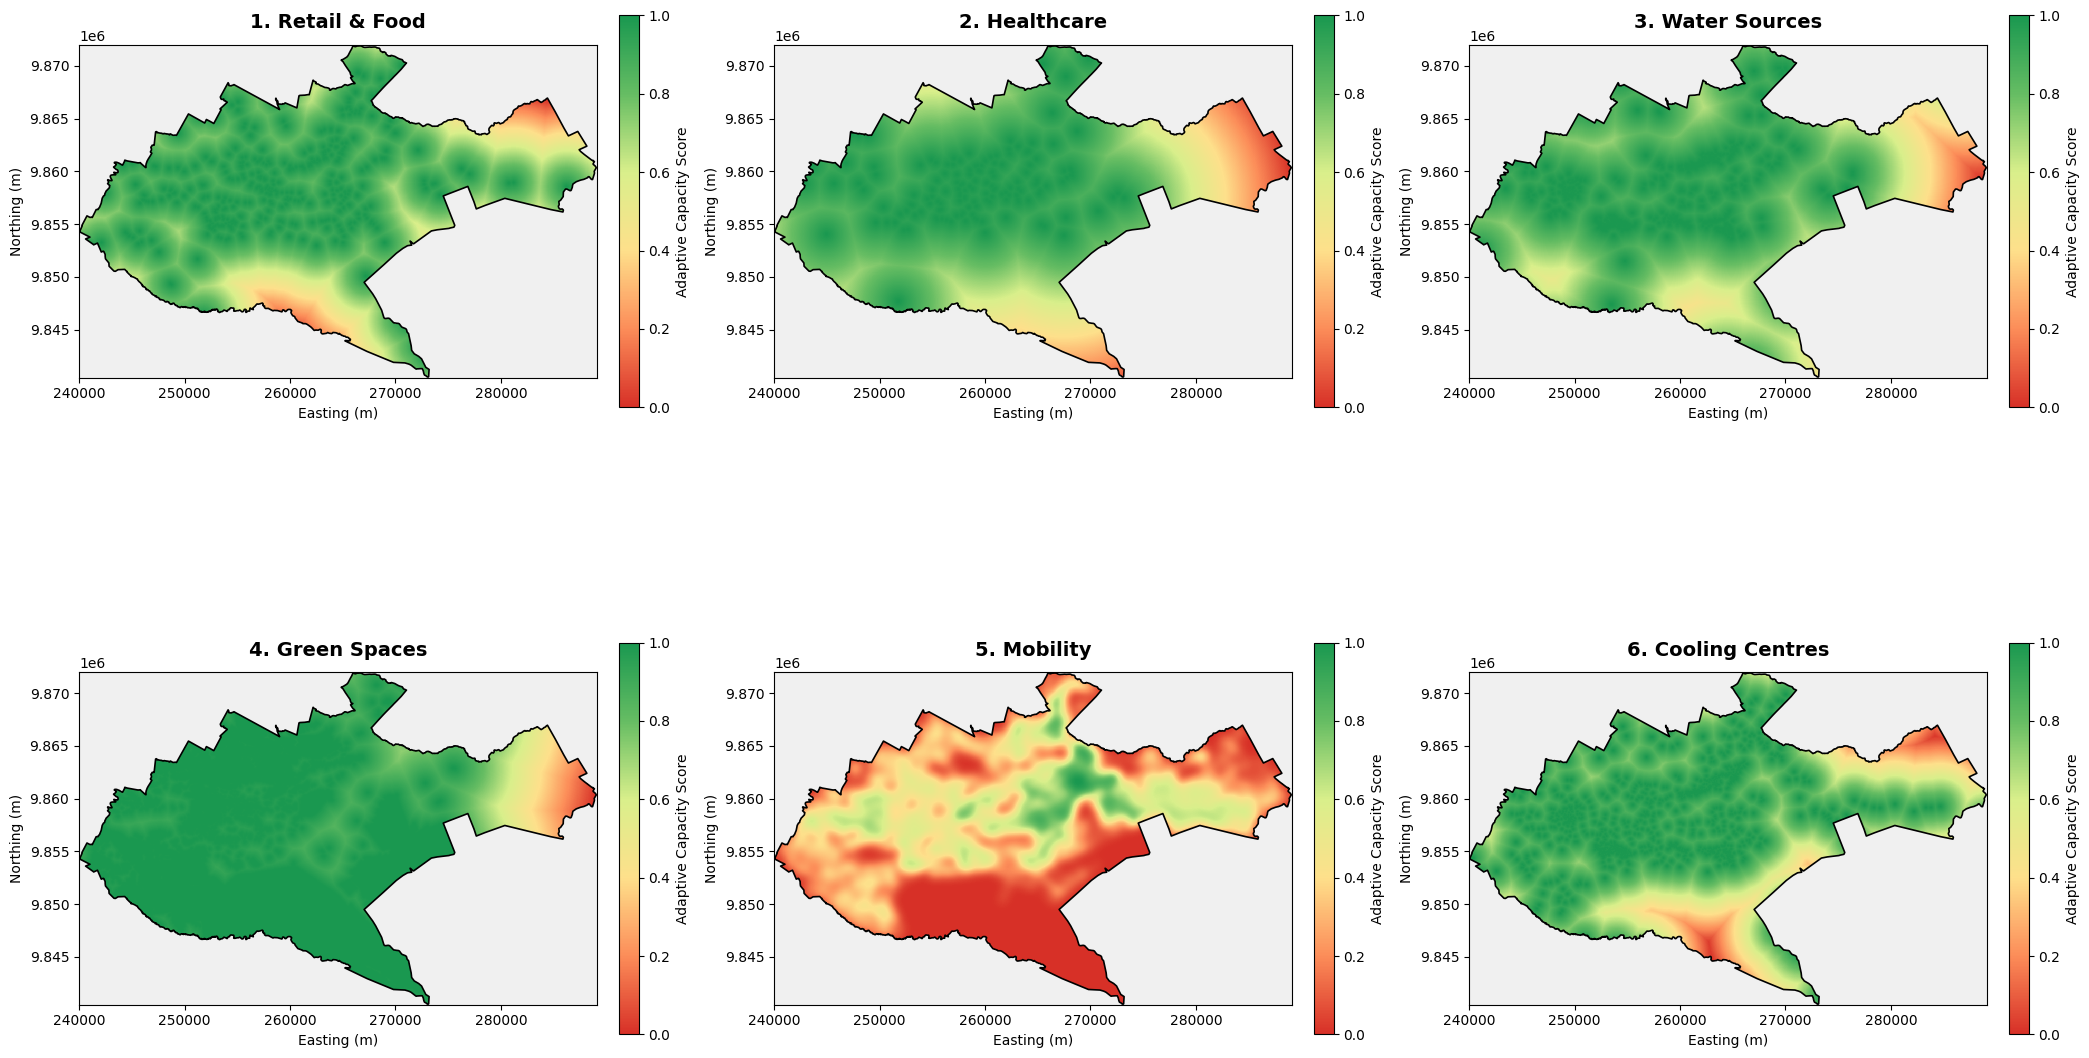

In [9]:
# --- Overview: all 6 individual layers side-by-side -----------------
layers_dict = {
    '1. Retail & Food':   retail_proximity,
    '2. Healthcare':      health_proximity,
    '3. Water Sources':   water_proximity,
    '4. Green Spaces':    green_proximity,
    '5. Mobility':        mobility,
    '6. Cooling Centres': cooling_proximity,
}

fig = plot_all_layers(layers_dict, grid)

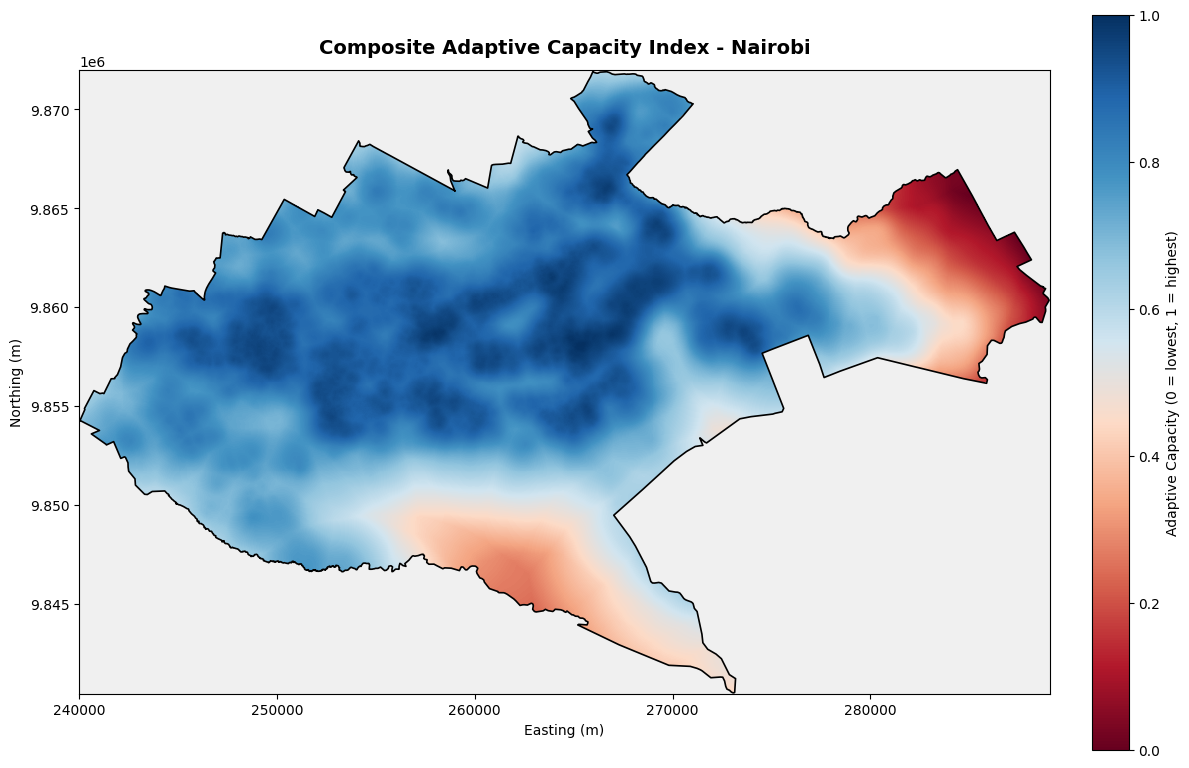

In [10]:
# --- Compute composite (equal weights) ----------------------------
layers_list = [
    retail_proximity,
    health_proximity,
    water_proximity,
    green_proximity,
    mobility,
    cooling_proximity,
]

# Equal weights: 1/6 each
ac_composite = compute_composite(layers_list)

# --- Plot the final Adaptive Capacity map -------------------------
fig, ax = plt.subplots(figsize=(12, 10))
plot_layer(
    ac_composite, grid,
    'Composite Adaptive Capacity Index - Nairobi',
    cmap=COMPOSITE_CMAP, ax=ax,
    cbar_label='Adaptive Capacity (0 = lowest, 1 = highest)'
)
plt.tight_layout()
plt.show()

Composite AC - min: 0.000  max: 1.000  mean: 0.705  std: 0.209


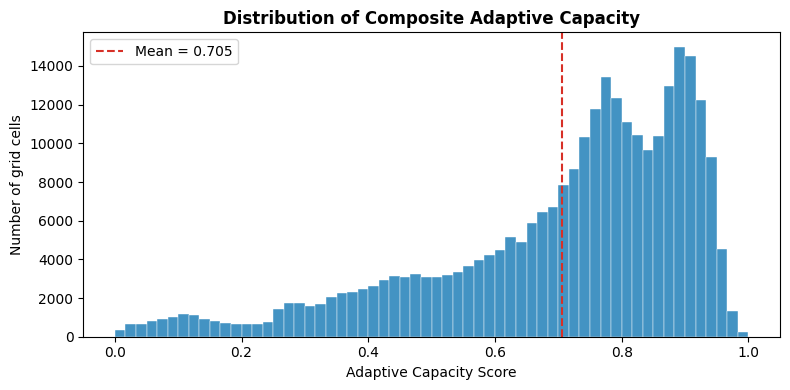

In [11]:
# --- Summary statistics ---
vals = ac_composite[~np.isnan(ac_composite)]
print(f"Composite AC - min: {vals.min():.3f}  max: {vals.max():.3f}  "
      f"mean: {vals.mean():.3f}  std: {vals.std():.3f}")

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vals, bins=60, color='#4393c3', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Adaptive Capacity Score')
ax.set_ylabel('Number of grid cells')
ax.set_title('Distribution of Composite Adaptive Capacity', fontweight='bold')
ax.axvline(vals.mean(), color='#d73027', linestyle='--', label=f'Mean = {vals.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
from src.export_web_maps import export_raw_for_web

# Assuming your base grid dictionary is called 'grid'
# Export the RAW data arrays:

export_raw_for_web(retail_proximity, grid, "retail_proximity")
export_raw_for_web(health_proximity, grid, "health_proximity")
export_raw_for_web(water_proximity, grid, "water_proximity")
export_raw_for_web(green_proximity, grid, "green_proximity")
export_raw_for_web(cooling_proximity, grid, "cooling_proximity")
export_raw_for_web(mobility, grid, "mobility_proximity")


Exported raw data for 'retail_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\retail_proximity_raw.png
Exported raw data for 'health_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\health_proximity_raw.png
Exported raw data for 'water_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\water_proximity_raw.png
Exported raw data for 'green_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\green_proximity_raw.png
Exported raw data for 'cooling_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\cooling_proximity_raw.png
Exported raw data for 'mobility_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-E